In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_csv('STD Cases.csv')

In [3]:
df.head()

,Disease,Disease Code,State,Year,Gender,Age,Age Code,STD Cases,Population,Rate per 100K
0,Chlamydia,274.0,Alabama,1996.0,Male,0-14 years,0-14,25.0,468394.0,5.34
1,Chlamydia,274.0,Alabama,1996.0,Male,15-19 years,15-19,164.0,165920.0,98.84
2,Chlamydia,274.0,Alabama,1996.0,Male,20-24 years,20-24,193.0,152848.0,126.27
3,Chlamydia,274.0,Alabama,1996.0,Male,25-29 years,25-29,88.0,152778.0,57.60
4,Chlamydia,274.0,Alabama,1996.0,Male,30-34 years,30-34,55.0,155850.0,35.29


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42680 entries, 0 to 42679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Disease        42530 non-null  object 
 1   Disease Code   42530 non-null  float64
 2   State          42530 non-null  object 
 3   Year           42530 non-null  float64
 4   Gender         42530 non-null  object 
 5   Age            42530 non-null  object 
 6   Age Code       42530 non-null  object 
 7   STD Cases      42530 non-null  float64
 8   Population     35483 non-null  float64
 9   Rate per 100K  35483 non-null  float64
dtypes: float64(5), object(5)
memory usage: 3.3+ MB


In [5]:
df.isnull().sum()

Disease           150
Disease Code      150
State             150
Year              150
Gender            150
Age               150
Age Code          150
STD Cases         150
Population       7197
Rate per 100K    7197
dtype: int64

In [6]:
# Drop rows where 'STD Cases' is null, as we can't predict without this target
df = df.dropna(subset=['STD Cases'])

# Impute missing categorical values with the most frequent value
for col in ['Disease', 'State', 'Gender', 'Age', 'Age Code']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Impute missing numerical values
# For 'Population' and 'Rate per 100K', use the median to avoid outliers affecting the mean
df['Population'].fillna(df['Population'].median(), inplace=True)
df['Rate per 100K'].fillna(df['Rate per 100K'].median(), inplace=True)

In [7]:
df.isnull().sum()

Disease          0
Disease Code     0
State            0
Year             0
Gender           0
Age              0
Age Code         0
STD Cases        0
Population       0
Rate per 100K    0
dtype: int64

In [8]:
df.empty

False

In [9]:
df.duplicated().sum()

0

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42530 entries, 0 to 42629
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Disease        42530 non-null  object 
 1   Disease Code   42530 non-null  float64
 2   State          42530 non-null  object 
 3   Year           42530 non-null  float64
 4   Gender         42530 non-null  object 
 5   Age            42530 non-null  object 
 6   Age Code       42530 non-null  object 
 7   STD Cases      42530 non-null  float64
 8   Population     42530 non-null  float64
 9   Rate per 100K  42530 non-null  float64
dtypes: float64(5), object(5)
memory usage: 3.6+ MB


In [11]:
#Looking for types of columns that we have
# Categorical columns 
cat_col = [col for col in df.columns if df[col].dtype == 'object'] 
print('Categorical columns :',cat_col) 
# Numerical columns 
num_col = [col for col in df.columns if df[col].dtype != 'object'] 
print('Numerical columns :',num_col)

Categorical columns : ['Disease', 'State', 'Gender', 'Age', 'Age Code']
Numerical columns : ['Disease Code', 'Year', 'STD Cases', 'Population', 'Rate per 100K']


In [12]:
le = LabelEncoder()

columns_to_encode = ['Disease', 'State', 'Gender', 'Age', 'Age Code']
for col in columns_to_encode:
    df[col] = le.fit_transform(df[col])

In [13]:
df.head()

,Disease,Disease Code,State,Year,Gender,Age,Age Code,STD Cases,Population,Rate per 100K
0,0,274.0,0,1996.0,1,0,0,25.0,468394.0,5.34
1,0,274.0,0,1996.0,1,1,1,164.0,165920.0,98.84
2,0,274.0,0,1996.0,1,2,2,193.0,152848.0,126.27
3,0,274.0,0,1996.0,1,3,3,88.0,152778.0,57.60
4,0,274.0,0,1996.0,1,4,4,55.0,155850.0,35.29


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42530 entries, 0 to 42629
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Disease        42530 non-null  int32  
 1   Disease Code   42530 non-null  float64
 2   State          42530 non-null  int32  
 3   Year           42530 non-null  float64
 4   Gender         42530 non-null  int32  
 5   Age            42530 non-null  int32  
 6   Age Code       42530 non-null  int32  
 7   STD Cases      42530 non-null  float64
 8   Population     42530 non-null  float64
 9   Rate per 100K  42530 non-null  float64
dtypes: float64(5), int32(5)
memory usage: 2.8 MB


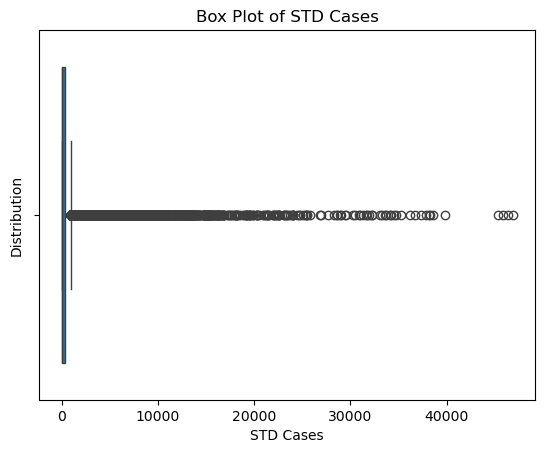

In [15]:
# Box plotting the Age column in order to find the outliers
sns.boxplot(data=df, x='STD Cases')
plt.xlabel('STD Cases')
plt.ylabel('Distribution')
plt.title('Box Plot of STD Cases')
plt.show()

In [16]:
# Labelling the dataset
X = df.drop(columns=['STD Cases'])
y = df['STD Cases']

In [17]:
# Splitting the datasets into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)
X_train.shape, X_test.shape

((31897, 9), (10633, 9))

In [18]:
# Preprocessing
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [19]:
from sklearn.metrics import classification_report, accuracy_score

# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predict and calculate accuracy
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"Random Forest Train Accuracy: {train_accuracy_rf:.4f}")
print(f"Random Forest Test Accuracy: {test_accuracy_rf:.4f}")

# Classification report for more metrics
print("\nClassification Report (Random Forest - Test Data):\n")
print(classification_report(y_test, y_test_pred_rf))

MemoryError: could not allocate 963379200 bytes

In [20]:
# Random Forest Classifier with reduced number of trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # Start with 100 trees
rf.fit(X_train, y_train)

# Predict and calculate accuracy
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"Random Forest Train Accuracy: {train_accuracy_rf:.4f}")
print(f"Random Forest Test Accuracy: {test_accuracy_rf:.4f}")

# Classification report for more metrics
print("\nClassification Report (Random Forest - Test Data):\n")
print(classification_report(y_test, y_test_pred_rf))

MemoryError: could not allocate 963379200 bytes